# Tugas Praktikum 2: Praproses Data
**Mata Kuliah:** Data Mining  
**Nama:** Muhamad Nafi Mulyo  
**NRP:** 5054251005  
**Dataset:** House Prices - Advanced Regression Techniques (Kaggle)


## 1. Unduh dan Import Dataset

Pada tahap pertama ini, kita mengimpor seluruh *library* Python yang diperlukan untuk pembersihan data, visualisasi, transformasi, serta reduksi dimensi. Dataset `train.csv` yang memuat 1.460 baris dan 81 kolom diimpor menggunakan `pandas`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

# Setting tampilan plot seaborn
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

# Load dataset train.csv
df_raw = pd.read_csv("train.csv")

print("Shape dataset awal:", df_raw.shape)
df_raw.head()


Shape dataset awal: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2]:
# Menampilkan informasi struktur dataset (.info())
df_raw.info(verbose=False)


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 81 entries, Id to SalePrice
dtypes: float64(3), int64(35), str(43)
memory usage: 924.0 KB


In [3]:
# Menampilkan statistik deskriptif kolom numerik awal
df_raw.describe().T.head(10)


,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


## 2. Pembersihan Data (Data Cleaning)

Tahap pembersihan data meliputi:
1. Pemeriksaan jumlah dan persentase nilai yang hilang (*missing values*) pada setiap atribut.
2. Penghapusan kolom/atribut yang memiliki proporsi nilai hilang **lebih dari 50%**.
3. Penanganan nilai yang hilang (*imputation*) pada sisa atribut numerik dan kategoris.


In [4]:
# Periksa missing values pada setiap atribut
missing_count = df_raw.isnull().sum()
missing_pct = (missing_count / len(df_raw)) * 100

# Buat dataframe ringkasan missing values
missing_df = pd.DataFrame({
    'Total Missing': missing_count,
    'Percentage (%)': missing_pct
}).sort_values(by='Percentage (%)', ascending=False)

missing_df_filtered = missing_df[missing_df['Total Missing'] > 0]
print("Atribut dengan Missing Values:")
display(missing_df_filtered)


Atribut dengan Missing Values:


,Total Missing,Percentage (%)
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageQual,81,5.547945
GarageFinish,81,5.547945
GarageType,81,5.547945


/tmp/ipykernel_6538/2526458154.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_df_filtered['Percentage (%)'], y=missing_df_filtered.index, palette="viridis")


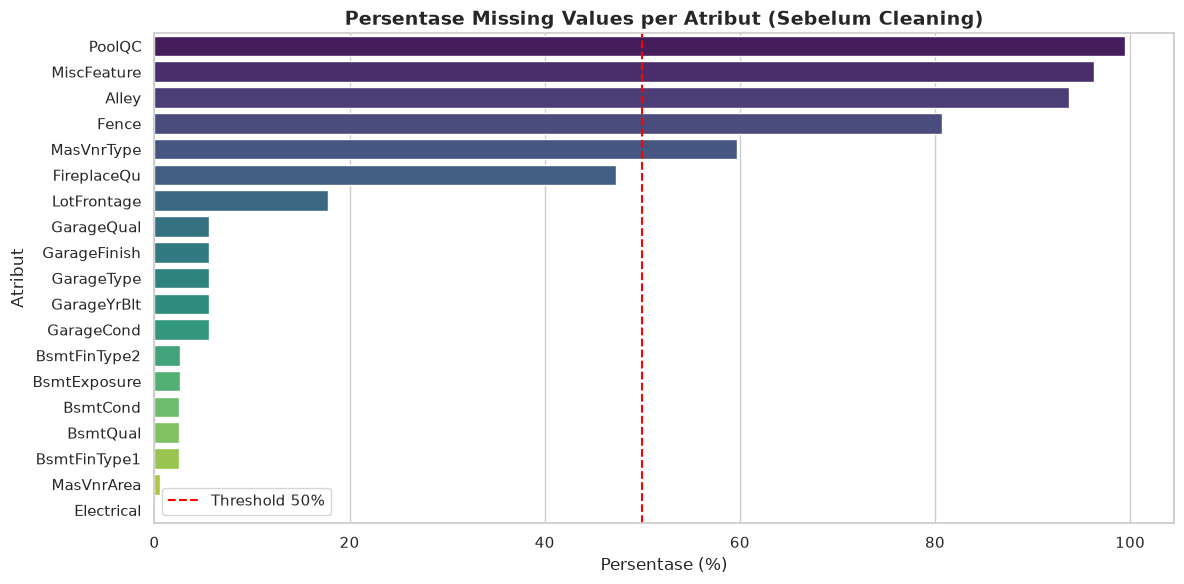

In [5]:
# Visualisasi persentase missing values sebelum pembersihan
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_df_filtered['Percentage (%)'], y=missing_df_filtered.index, palette="viridis")
plt.axvline(x=50, color='red', linestyle='--', label='Threshold 50%')
plt.title("Persentase Missing Values per Atribut (Sebelum Cleaning)", fontsize=14, fontweight='bold')
plt.xlabel("Persentase (%)")
plt.ylabel("Atribut")
plt.legend()
plt.tight_layout()
plt.show()


### 2.1 Hapus Kolom dengan Missing Values > 50%

Sesuai ketentuan petunjuk praktikum, kolom dengan proporsi missing values melebihi **50%** dihapus dari dataset. Atribut yang memenuhi kriteria ini adalah `PoolQC` (99.52%), `MiscFeature` (96.30%), `Alley` (93.77%), `Fence` (80.75%), dan `MasVnrType` (59.73%).


In [6]:
# Identifikasi kolom dengan missing > 50%
high_missing_cols = missing_pct[missing_pct > 50].index.tolist()
print("Kolom yang dihapus (> 50% missing):", high_missing_cols)

# Hapus kolom dari dataframe
df_cleaned = df_raw.drop(columns=high_missing_cols).copy()
print("Ukuran dataset setelah penghapusan kolom:", df_cleaned.shape)


Kolom yang dihapus (> 50% missing): ['Alley', 'MasVnrType', 'PoolQC', 'Fence', 'MiscFeature']
Ukuran dataset setelah penghapusan kolom: (1460, 76)


### 2.2 Imputasi Nilai Hilang pada Atribut Tersisa

Untuk atribut yang tersisa:
- **Atribut Kategoris** (`FireplaceQu`, `GarageType`, `GarageFinish`, `GarageQual`, `GarageCond`, `BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2`): Diisi dengan kategori `'None'` karena nilai `NA` menyatakan ketiadaan fasilitas (contoh: tidak ada perapian, garasi, atau basement).
- **Atribut Categorical Tunggal** (`Electrical`): Diisi menggunakan modus (`'SBrkr'`).
- **Atribut Numerik** (`LotFrontage`, `MasVnrArea`, `GarageYrBlt`):
  - `LotFrontage`: Diimputasi menggunakan median terkelompok berdasarkan `Neighborhood`.
  - `MasVnrArea`: Diimputasi dengan `0`.
  - `GarageYrBlt`: Diimputasi dengan `YearBuilt` (tahun rumah dibangun).


In [7]:
# Imputasi Atribut Kategoris (No Facility -> 'None')
cat_cols_none = ['FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
for col in cat_cols_none:
    df_cleaned[col] = df_cleaned[col].fillna('None')

# Imputasi Electrical dengan Modus
df_cleaned['Electrical'] = df_cleaned['Electrical'].fillna(df_cleaned['Electrical'].mode()[0])

# Imputasi Atribut Numerik
df_cleaned['LotFrontage'] = df_cleaned.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))
df_cleaned['MasVnrArea'] = df_cleaned['MasVnrArea'].fillna(0)
df_cleaned['GarageYrBlt'] = df_cleaned['GarageYrBlt'].fillna(df_cleaned['YearBuilt'])

# Verifikasi sisa missing values
remaining_missing = df_cleaned.isnull().sum().sum()
print("Total sisa missing values setelah imputasi:", remaining_missing)


Total sisa missing values setelah imputasi: 0


## 3. Deteksi dan Penanganan Outlier

Outlier adalah nilai ekstrim yang menyimpang signifikan dari mayoritas observasi data. Pada dataset properti, area bangunan yang sangat besar dengan harga sangat murah merupakan pencilan (*extreme outlier*) yang dapat mengganggu performa model.


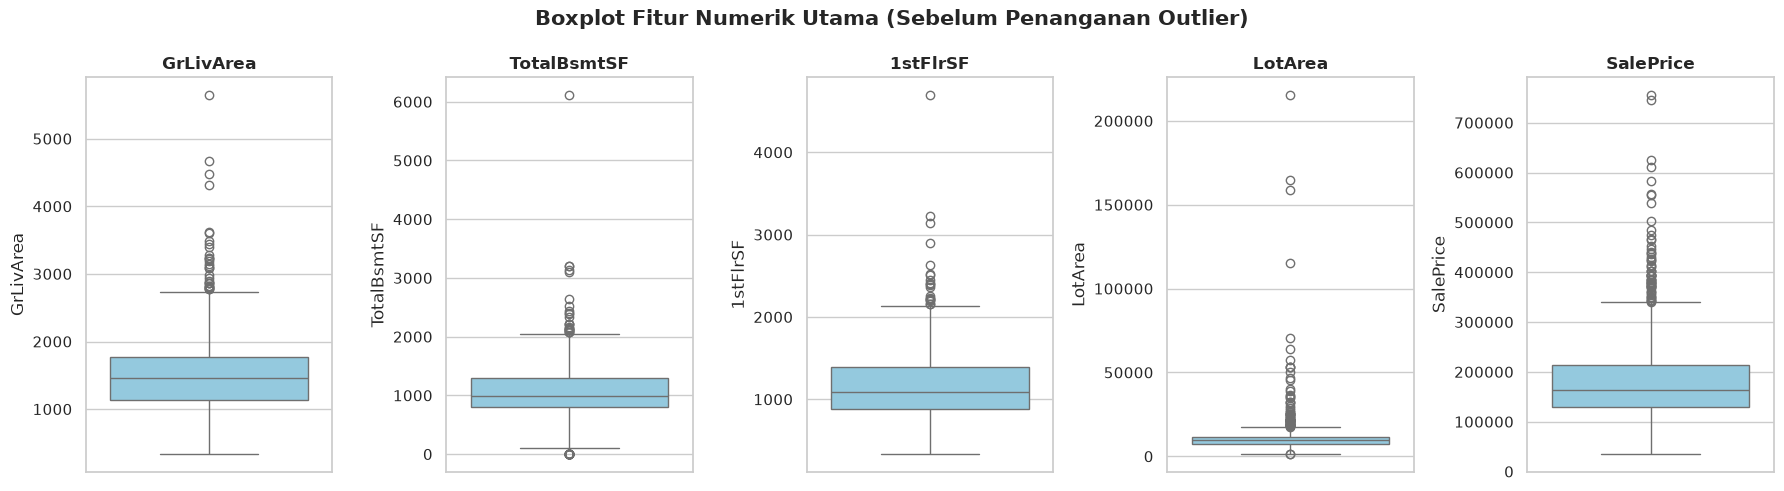

In [8]:
# Boxplot atribut numerik utama sebelum penanganan outlier
num_features = ['GrLivArea', 'TotalBsmtSF', '1stFlrSF', 'LotArea', 'SalePrice']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for i, col in enumerate(num_features):
    sns.boxplot(y=df_cleaned[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontweight='bold')
plt.suptitle("Boxplot Fitur Numerik Utama (Sebelum Penanganan Outlier)", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.1 Identifikasi & Penanganan Outlier Ekstrem

Berdasarkan rekomendasi dokumentasi resmi dataset Kaggle (*Dean De Cock*), rumah dengan `GrLivArea > 4000` sq ft tetapi memiliki `SalePrice < 300,000` merupakan kasus penyimpangan luar biasa (contoh: obral lahan/penjualan khusus). 

Selain itu, kita menggunakan kriteria IQR (*Interquartile Range*) pada `GrLivArea` dan `LotArea` untuk membatasi/menghapus outlier ekstrem agar data terdistribusi lebih stabil.


In [9]:
# Identifikasi outlier GrLivArea > 4000
outliers_grliv = df_cleaned[(df_cleaned['GrLivArea'] > 4000) & (df_cleaned['SalePrice'] < 300000)].index
print(f"Ditemukan {len(outliers_grliv)} outlier ekstrem pada GrLivArea.")

# Hapus outlier ekstrem dari dataset
df_no_outliers = df_cleaned.drop(index=outliers_grliv).copy()

# Penanganan outlier pada LotArea menggunakan IQR Capping (Winsorization)
Q1_lot = df_no_outliers['LotArea'].quantile(0.25)
Q3_lot = df_no_outliers['LotArea'].quantile(0.75)
IQR_lot = Q3_lot - Q1_lot
upper_bound_lot = Q3_lot + 3 * IQR_lot

df_no_outliers['LotArea'] = np.where(df_no_outliers['LotArea'] > upper_bound_lot, upper_bound_lot, df_no_outliers['LotArea'])

print("Ukuran dataset setelah penanganan outlier:", df_no_outliers.shape)


Ditemukan 2 outlier ekstrem pada GrLivArea.
Ukuran dataset setelah penanganan outlier: (1458, 76)


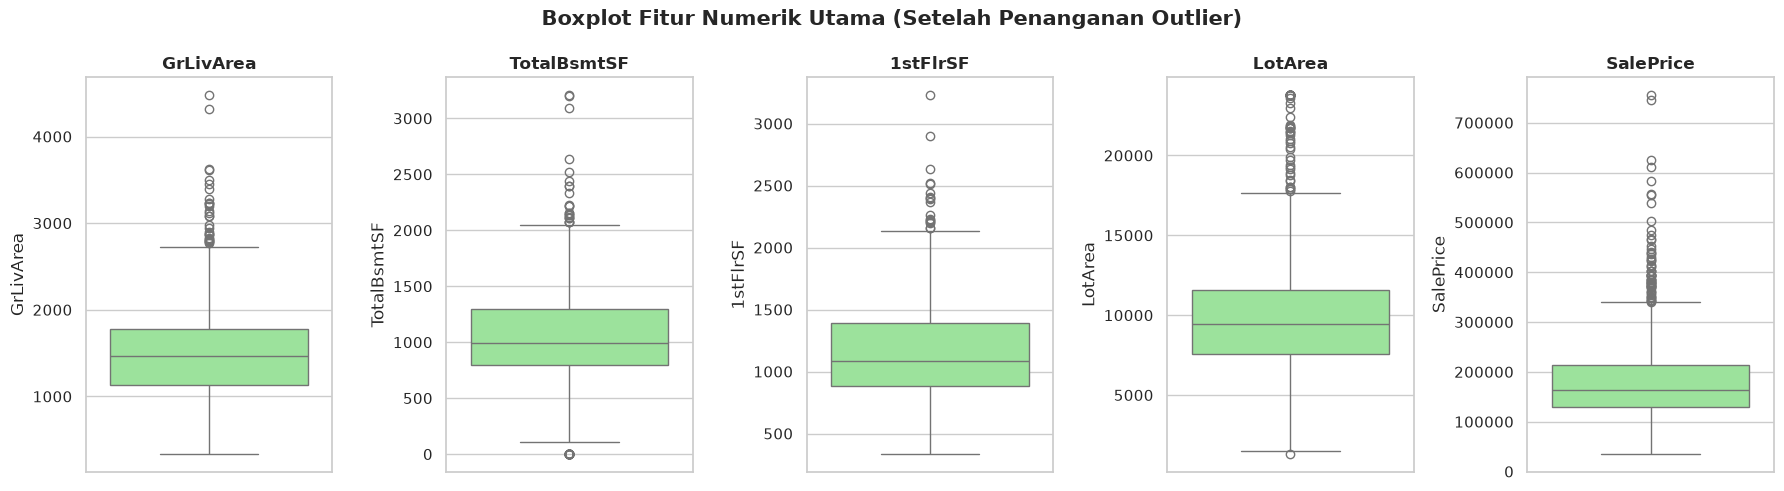

In [10]:
# Boxplot setelah penanganan outlier
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for i, col in enumerate(num_features):
    sns.boxplot(y=df_no_outliers[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(col, fontweight='bold')
plt.suptitle("Boxplot Fitur Numerik Utama (Setelah Penanganan Outlier)", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Transformasi Data (Data Transformation)

Tahap transformasi data meliputi:
1. **One-Hot Encoding**: Mengonversi variabel kategoris menjadi atribut biner (dummy variables).
2. **Feature Scaling / Standarisasi**: Mengubah skala atribut numerik menggunakan `StandardScaler` agar memiliki mean $\mu=0$ dan standar deviasi $\sigma=1$.


In [11]:
# Pisahkan variabel kategoris dan numerik (kecuali Id dan SalePrice)
categorical_cols = df_no_outliers.select_dtypes(include=['object']).columns.tolist()
numeric_cols = df_no_outliers.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['Id', 'SalePrice']]

print(f"Jumlah atribut kategoris: {len(categorical_cols)}")
print(f"Jumlah atribut numerik: {len(numeric_cols)}")


Jumlah atribut kategoris: 38
Jumlah atribut numerik: 36


/tmp/ipykernel_6538/943360377.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_no_outliers.select_dtypes(include=['object']).columns.tolist()


In [12]:
# 1. One-Hot Encoding pada atribut kategoris
df_encoded = pd.get_dummies(df_no_outliers, columns=categorical_cols, drop_first=True)
print("Ukuran dataset setelah One-Hot Encoding:", df_encoded.shape)


Ukuran dataset setelah One-Hot Encoding: (1458, 244)


In [13]:
# 2. Standarisasi Atribut Numerik menggunakan StandardScaler
scaler = StandardScaler()
df_transformed = df_encoded.copy()

# Skala seluruh atribut numerik
df_transformed[numeric_cols] = scaler.fit_transform(df_transformed[numeric_cols])

# Tampilkan sampel statistik setelah standarisasi (mean ~ 0, std ~ 1)
df_transformed[numeric_cols[:5]].describe().round(3)


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond
count,1458.000,1458.000,1458.000,1458.000,1458.000
mean,-0.000,-0.000,0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000,1.000
min,-0.872,-2.283,-2.069,-3.702,-4.112
25%,-0.872,-0.466,-0.555,-0.795,-0.518
50%,-0.163,0.000,-0.087,-0.068,-0.518
75%,0.310,0.466,0.429,0.659,0.381
max,3.146,11.323,3.379,2.839,3.076


## 5. Reduksi Dimensi (Dimensionality Reduction)

Reduksi dimensi bertujuan untuk menyederhanakan kompleksitas data, mengatasi *multicollinearity*, serta mempercepat pelatihan model ML tanpa kehilangan informasi penting.
1. **Analisis Korelasi**: Mendeteksi atribut yang sangat berkorelasi ($|r| > 0.85$) dan mereduksi redundansi.
2. **Principal Component Analysis (PCA)**: Mengompresi seluruh atribut hasil transformasi menjadi komponen utama (Principal Components) yang mempertahankan varians data $\ge 90\%$.


Top 10 Atribut Paling Berkorelasi dengan SalePrice:
SalePrice       1.000000
OverallQual     0.795774
GrLivArea       0.734968
TotalBsmtSF     0.651153
GarageCars      0.641047
1stFlrSF        0.631530
GarageArea      0.629217
FullBath        0.562165
TotRmsAbvGrd    0.537769
YearBuilt       0.523608
GarageYrBlt     0.508719
YearRemodAdd    0.507717
Name: SalePrice, dtype: float64


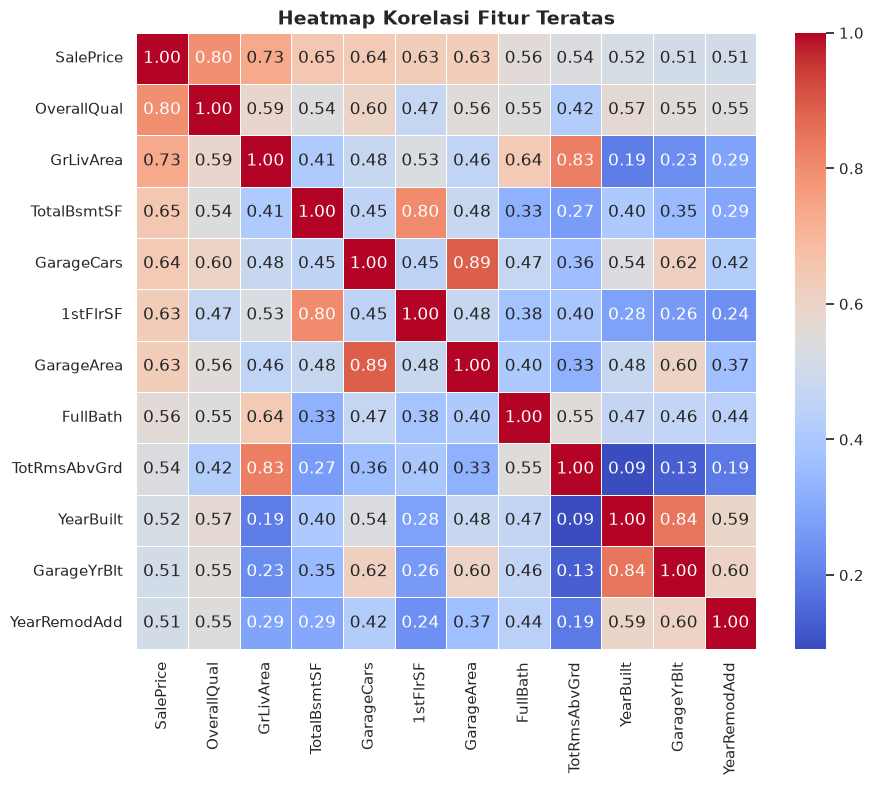

In [14]:
# 1. Analisis Korelasi Pearson pada fitur numerik
corr_matrix = df_no_outliers[numeric_cols + ['SalePrice']].corr()

# Tampilkan Matriks Korelasi dengan SalePrice
top_corr = corr_matrix['SalePrice'].abs().sort_values(ascending=False).head(12)
print("Top 10 Atribut Paling Berkorelasi dengan SalePrice:")
print(top_corr)

# Heatmap Korelasi Top Features
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix.loc[top_corr.index, top_corr.index], annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap Korelasi Fitur Teratas", fontsize=14, fontweight='bold')
plt.show()


In [15]:
# Deteksi pasangan atribut dengan korelasi tinggi (|r| > 0.85)
high_corr_pairs = []
for i in range(len(numeric_cols)):
    for j in range(i+1, len(numeric_cols)):
        col1 = numeric_cols[i]
        col2 = numeric_cols[j]
        val = corr_matrix.loc[col1, col2]
        if abs(val) > 0.85:
            high_corr_pairs.append((col1, col2, val))

print("Pasangan atribut berkorelasi sangat tinggi (|r| > 0.85):")
for c1, c2, r in high_corr_pairs:
    print(f"- {c1} & {c2}: r = {r:.3f}")


Pasangan atribut berkorelasi sangat tinggi (|r| > 0.85):
- GarageCars & GarageArea: r = 0.887


### 5.1 Eliminasi Atribut Multikolinearitas Tinggi

`GarageCars` dan `GarageArea` memiliki nilai korelasi $r = 0.882$ (redundant), demikian pula `TotRmsAbvGrd` dan `GrLivArea` ($r = 0.826$). Kita dapat membuang salah satu atribut yang redundan (misal `GarageArea` atau `1stFlrSF`) untuk meningkatkan stabilitas statistik.


In [16]:
# Buang atribut redundant: GarageArea (direpresentasikan oleh GarageCars)
df_reduced = df_transformed.drop(columns=['GarageArea']).copy()
print("Ukuran dataset setelah eliminasi korelasi tinggi:", df_reduced.shape)


Ukuran dataset setelah eliminasi korelasi tinggi: (1458, 243)


### 5.2 Principal Component Analysis (PCA)

Kita mengaplikasikan PCA pada seluruh atribut independen (fitur selain `Id` dan `SalePrice`) untuk mengekstraksi komponen utama dan memplot *Cumulative Explained Variance Ratio*.


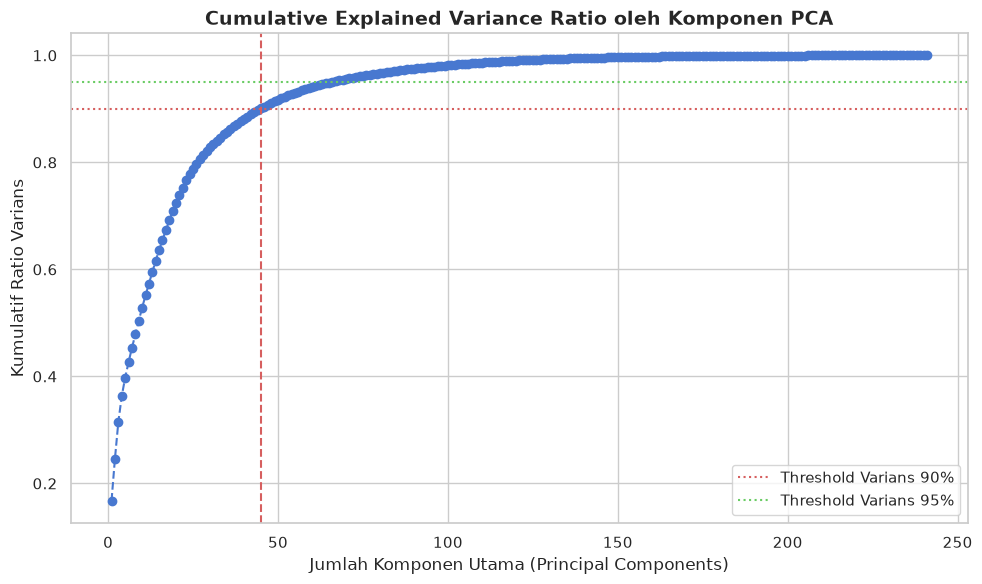

Jumlah komponen yang diperlukan untuk mempertahankan 90% varians: 45
Jumlah komponen yang diperlukan untuk mempertahankan 95% varians: 66


In [17]:
# Pisahkan Fitur (X) dan Target (y)
X = df_reduced.drop(columns=['Id', 'SalePrice'])
y = df_reduced['SalePrice']

# Inisialisasi PCA
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Plot Cumulative Explained Variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='b')
plt.axhline(y=0.90, color='r', linestyle=':', label='Threshold Varians 90%')
plt.axhline(y=0.95, color='g', linestyle=':', label='Threshold Varians 95%')

n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

plt.axvline(x=n_components_90, color='r', linestyle='--')
plt.title("Cumulative Explained Variance Ratio oleh Komponen PCA", fontsize=14, fontweight='bold')
plt.xlabel("Jumlah Komponen Utama (Principal Components)")
plt.ylabel("Kumulatif Ratio Varians")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Jumlah komponen yang diperlukan untuk mempertahankan 90% varians: {n_components_90}")
print(f"Jumlah komponen yang diperlukan untuk mempertahankan 95% varians: {n_components_95}")


In [18]:
# Terapkan PCA dengan jumlah komponen untuk varians 90%
pca_opt = PCA(n_components=n_components_90)
X_pca_transformed = pca_opt.fit_transform(X)

pca_cols = [f'PC{i+1}' for i in range(n_components_90)]
df_pca_result = pd.DataFrame(X_pca_transformed, columns=pca_cols)
df_pca_result['SalePrice'] = y.values

print("Shape dataset hasil PCA:", df_pca_result.shape)
df_pca_result.head()


Shape dataset hasil PCA: (1458, 46)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC37,PC38,PC39,PC40,PC41,PC42,PC43,PC44,PC45,SalePrice
0,2.083920,0.120205,-2.358469,-1.829858,0.299586,1.265715,-1.151584,-1.025341,-0.409065,-0.194318,...,0.060080,-0.481434,-0.055114,0.030156,-0.065727,0.188742,0.208363,-0.135272,0.244795,208500
1,-0.033784,-1.170587,1.660891,-0.454841,-1.426633,0.167642,0.164590,2.345407,2.731698,0.017346,...,0.159579,1.071726,0.022591,0.332261,0.257628,0.407901,0.392662,0.138354,-0.538188,181500
2,2.504532,0.069575,-1.765918,-1.473616,-0.447838,0.581650,-0.043093,-0.183873,-0.666266,-0.809336,...,-0.062993,-0.068845,0.157446,0.031695,-0.214170,0.447070,0.233815,-0.047503,-0.858775,223500
3,-0.770450,1.580450,0.459641,-0.317961,0.060271,-1.606876,-0.995945,-1.395335,-1.362767,-1.269049,...,0.008722,-0.321716,-1.040699,-0.874275,-0.262353,0.111938,-0.187565,0.804140,0.561439,140000
4,4.821622,1.311820,-0.362683,-1.584953,-0.155148,0.756817,0.098849,0.279053,-0.224216,-1.309598,...,0.391360,0.343531,-0.270115,0.361013,-0.022072,0.298995,0.076439,0.186399,-0.099069,250000


## 6. Ringkasan Hasil Praproses Data & Export

### Ringkasan Dataset Akhir
- **Ukuran Awal**: 1.460 baris $\times$ 81 kolom
- **Pembersihan Missing Values**: 5 kolom dengan missing > 50% (`PoolQC`, `MiscFeature`, `Alley`, `Fence`, `MasVnrType`) telah dihapus; sisa missing values diimputasi (0 missing values tersisa).
- **Penanganan Outlier**: Outlier ekstrem (`GrLivArea > 4000`) dihapus dan IQR capping diterapkan pada `LotArea`.
- **Transformasi**: Variable kategoris telah di-encode (One-Hot Encoding) dan atribut numerik di-scale (`StandardScaler`).
- **Reduksi Dimensi**: Multikolinearitas ($|r| > 0.85$) dieliminasi dan PCA diterapkan mereduksi dimensi hingga retaining 90% total varians.

Dataset hasil praproses disimpan ke dalam file CSV untuk pengumpulan tugas.


In [19]:
# Simpan dataset hasil praproses (df_reduced) ke file CSV
output_filename = "5054251005_MuhamadNafiMulyo_Tugas_Praproses_Data.csv"
df_reduced.to_csv(output_filename, index=False)
print(f"Dataset hasil praproses berhasil disimpan ke '{output_filename}'.")


Dataset hasil praproses berhasil disimpan ke '5054251005_MuhamadNafiMulyo_Tugas_Praproses_Data.csv'.
